<a href="https://www.kaggle.com/code/sonawanelalitsunil/student-exam-scores-dataset-ml-93-03?scriptVersionId=260771385" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/student-exam-scores-dataset/student_exam_scores.csv


## Title:
📘 Student Exam Scores Dataset

## Description:
The Student Exam Scores dataset provides information about students’ academic performance across different subjects. It typically includes details such as student demographics (e.g., gender, parental education, study time, and socio-economic background), along with their exam results in core subjects like Math, Reading, and Writing.

This dataset is widely used in education analytics and machine learning projects to:

Analyze factors influencing student performance.

Build predictive models to estimate exam scores.

Explore correlations between study habits, parental involvement, and outcomes.

Support research in educational psychology, policy-making, and academic improvement strategies.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/student-exam-scores-dataset/student_exam_scores.csv")

In [3]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [4]:
df.tail()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0
199,S200,10.2,6.3,97.4,68,37.8


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [6]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [7]:
df.dtypes

student_id             object
hours_studied         float64
sleep_hours           float64
attendance_percent    float64
previous_scores         int64
exam_score            float64
dtype: object

In [8]:
df.shape

(200, 6)

In [9]:
df.isnull().sum()

student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

## Data visualizations

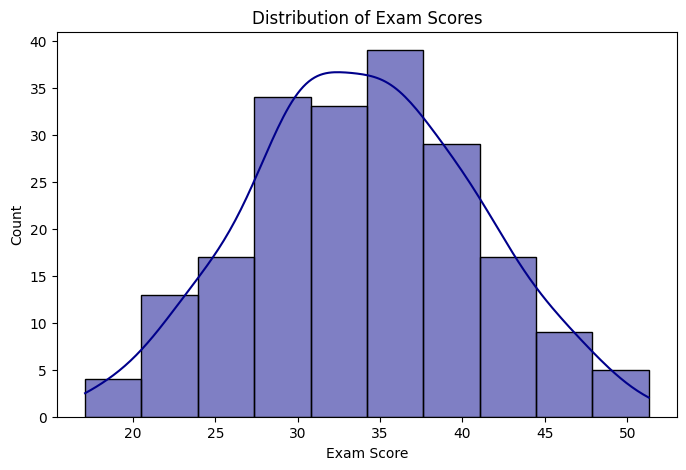

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], bins=10, kde=True, color="darkblue")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Count")
plt.show()


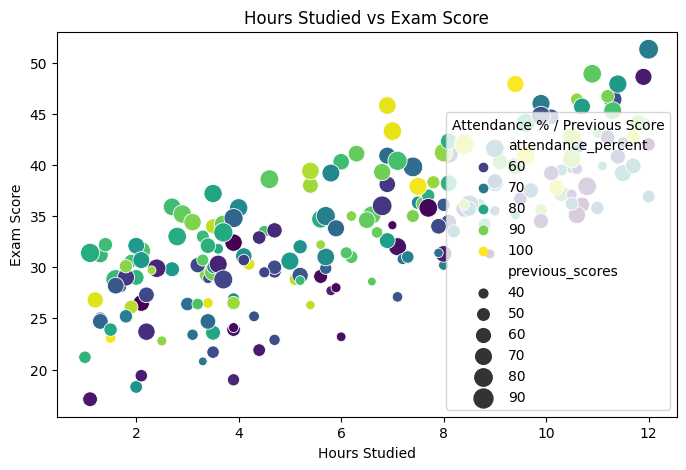

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='hours_studied', y='exam_score', data=df,
                hue="attendance_percent", palette="viridis",
                size="previous_scores", sizes=(40,200))
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend(title="Attendance % / Previous Score")
plt.show()

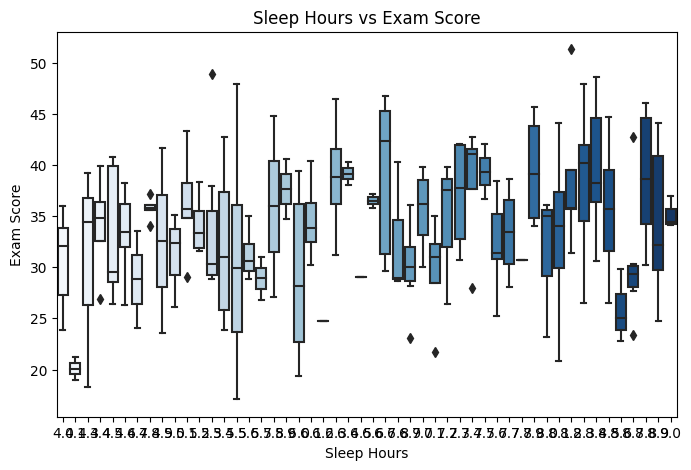

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sleep_hours', y='exam_score', data=df, palette="Blues")
plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")
plt.show()

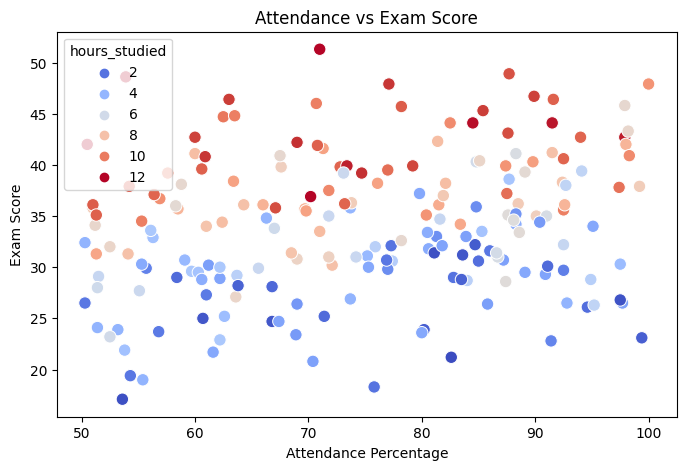

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='attendance_percent', y='exam_score', data=df,
                hue="hours_studied", palette="coolwarm", s=80)
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Score")
plt.show()


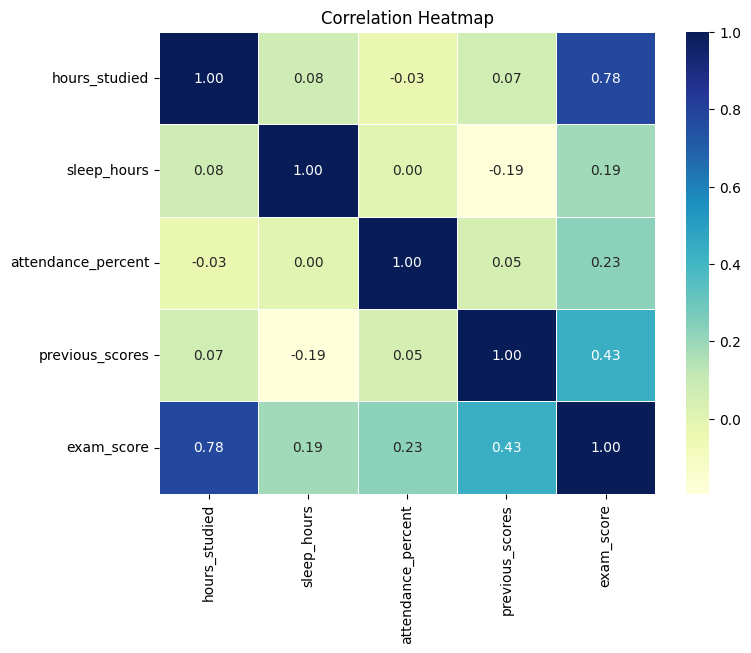

In [16]:
plt.figure(figsize=(8,6))
corr = df[['hours_studied','sleep_hours','attendance_percent','previous_scores','exam_score']].corr()
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


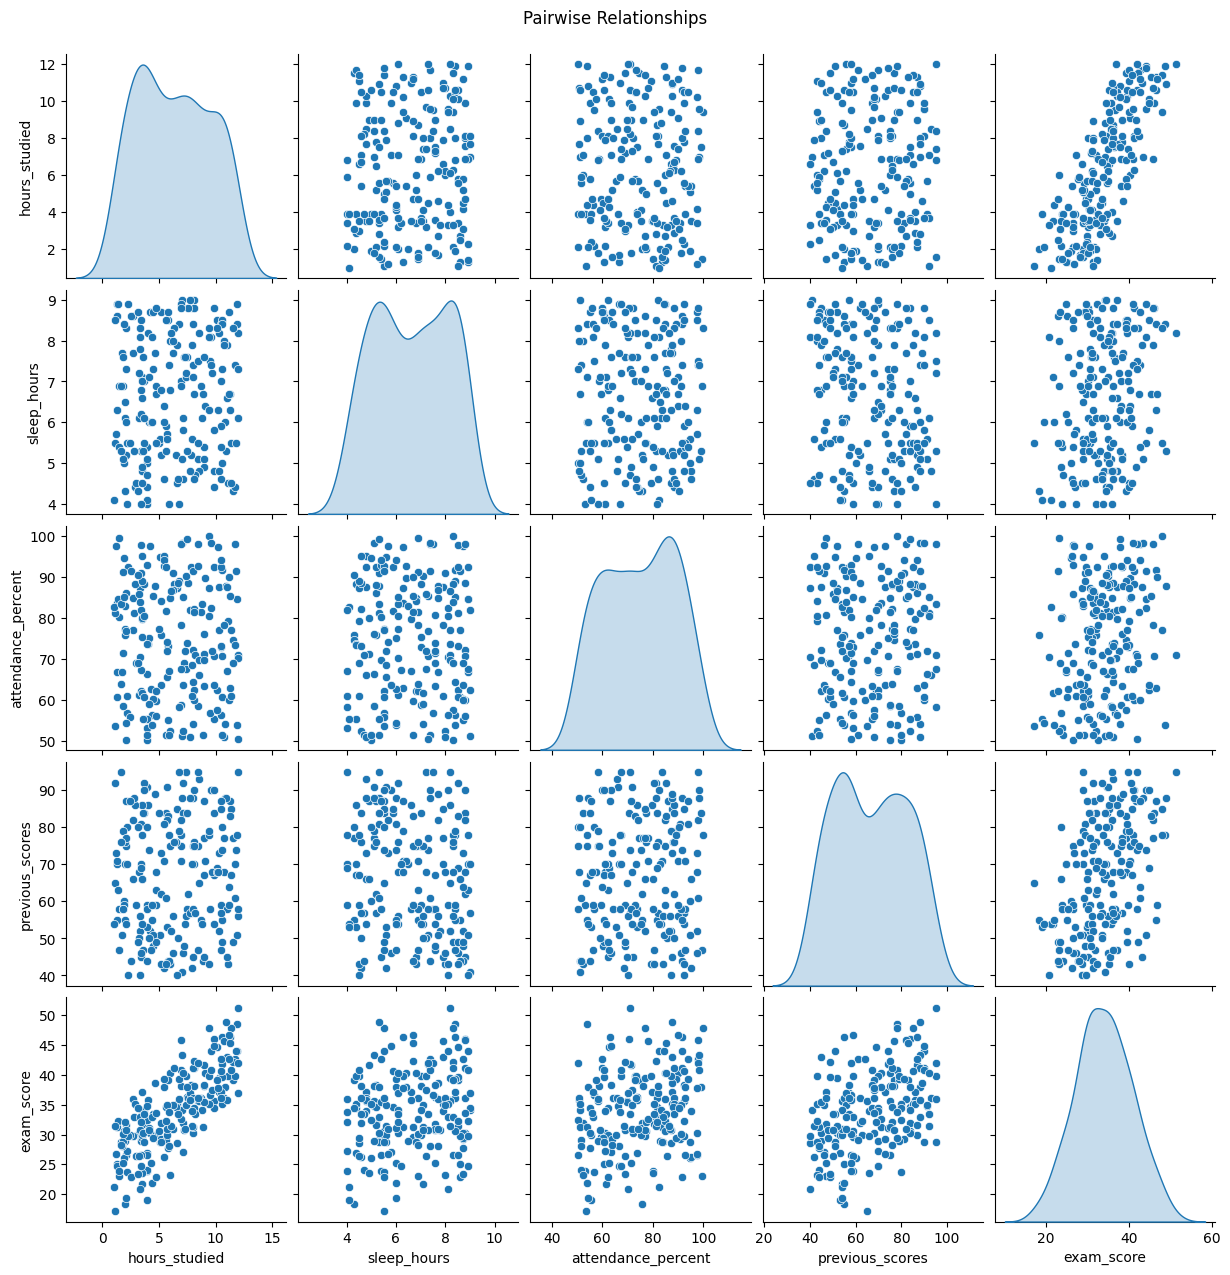

In [17]:
sns.pairplot(df[['hours_studied','sleep_hours','attendance_percent','previous_scores','exam_score']],
             diag_kind="kde", palette="muted")
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [19]:
X = df[['hours_studied','sleep_hours','attendance_percent','previous_scores']]
y = df['exam_score']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR(kernel='rbf')
}

In [23]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred) * 100   # in percentage
    mape = (1 - mean_absolute_percentage_error(y_test, y_pred)) * 100  # accuracy in %
    
    results[name] = {"R2 Score %": round(r2, 2), "Accuracy (MAPE %)": round(mape, 2)}

# Show results
results_df = pd.DataFrame(results).T
print(results_df)

                   R2 Score %  Accuracy (MAPE %)
Linear Regression       85.37              93.03
Decision Tree           53.34              86.56
Random Forest           79.44              91.02
Gradient Boosting       77.69              91.15
KNN                     78.21              91.07
SVM                     69.95              89.89


Model Performance (in %):

                   R2 Score %  Accuracy (MAPE %)
Linear Regression       85.37              93.03
Decision Tree           53.34              86.56
Random Forest           79.44              91.02
Gradient Boosting       77.69              91.15
KNN                     78.21              91.07
SVM                     69.95              89.89


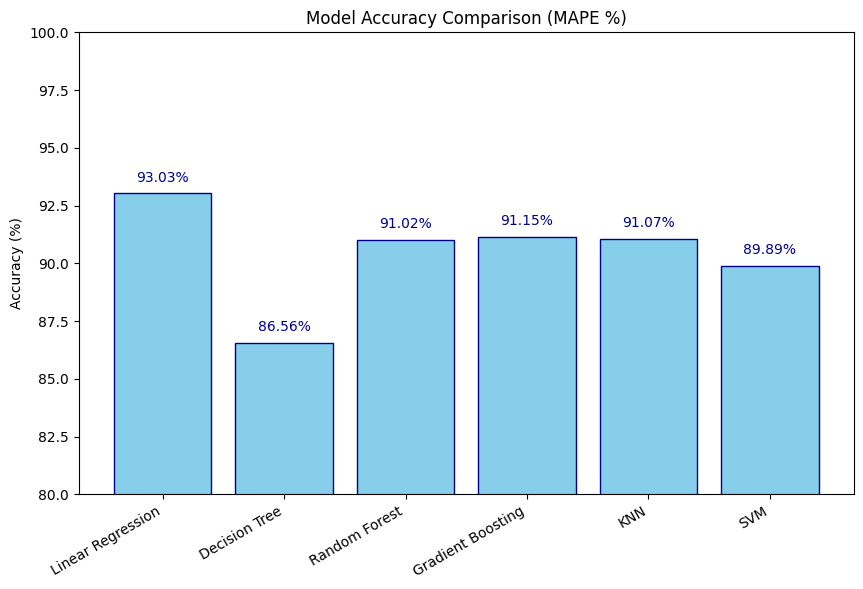

In [24]:

results_df = pd.DataFrame({
    "R2 Score %": [85.37, 53.34, 79.44, 77.69, 78.21, 69.95],
    "Accuracy (MAPE %)": [93.03, 86.56, 91.02, 91.15, 91.07, 89.89]
}, index=["Linear Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "KNN", "SVM"])

# Print table nicely
print("Model Performance (in %):\n")
print(results_df)

# ---- Bar Chart for Accuracy ----
plt.figure(figsize=(10,6))
bars = plt.bar(results_df.index, results_df["Accuracy (MAPE %)"], color="skyblue", edgecolor="darkblue")

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f"{height:.2f}%", ha='center', fontsize=10, color="darkblue")

plt.title("Model Accuracy Comparison (MAPE %)")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(80, 100)
plt.show()

## Thank you...pls upvote!!!